In [21]:
# --- Librerías para manejo de datos ---
import pandas as pd          # Para trabajar con tablas (DataFrames)
import numpy as np            # Para operaciones matemáticas (raíz cuadrada, etc.)

# --- Librerías de Machine Learning (scikit-learn) ---
from sklearn.model_selection import train_test_split   # Dividir datos en entrenamiento y prueba
from sklearn.compose import ColumnTransformer          # Aplicar transformaciones distintas a cada columna
from sklearn.preprocessing import OneHotEncoder        # Convertir categorías (texto) a números (0/1)
from sklearn.pipeline import Pipeline                  # Encadenar pasos de preprocesamiento + modelo
from sklearn.linear_model import LinearRegression      # El modelo de regresión lineal
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Métricas de error

# --- Visualización ---
import matplotlib.pyplot as plt  # Gráficos


In [22]:
#Cargar DataSet

df= pd.read_csv("/Users/miltonvanegasdelgado/Desktop/SEMESTRE 2/ELECTIVA MACHINE LEARNING/CLASE 2/machine-learning-intep/ventas_ml_clase2.csv")
df.head()


,marketing,precio,temporada,tienda,canal,ventas
0,5548.49,25.74,2,Sur,Tienda,461.70
1,3128.03,31.60,3,Occidente,Tienda,229.12
2,6350.81,37.94,3,Centro,Tienda,397.16
3,6693.02,34.28,3,Norte,Tienda,458.31
4,1488.14,30.45,1,Occidente,Tienda,197.70


In [23]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print("")

print("Tipos de Datos:")
for col, type in df.dtypes.items():
    print(f" {col:12s} {type}")
    


Filas: 1200, Columnas: 6

Tipos de Datos:
 marketing    float64
 precio       float64
 temporada    int64
 tienda       object
 canal        object
 ventas       float64


In [24]:
df.describe(include="all").transpose().head()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
marketing,1200.0,NaN,NaN,NaN,4961.787167,1768.35789,0.0,3772.115,5006.215,6107.785,10721.94
precio,1200.0,NaN,NaN,NaN,34.560042,7.154758,13.55,29.915,34.91,39.245,55.4
temporada,1200.0,NaN,NaN,NaN,2.5125,1.112449,1.0,2.0,3.0,3.0,4.0
tienda,1200,5,Norte,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canal,1200,3,Tienda,702,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
#Predecir las ventas usando las variables: marketing, precio, temporada, tienda, canal

X = df[["marketing", "precio", "temporada", "tienda", "canal"]]
Y = df["ventas"]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento: {X_train.shape[0]} filas ({X_train.shape[0]/len(df)*100} columnas)")
print(f"Datos de Prueba: {X_test.shape[0]} filas ({X_test.shape[0]/len(df)*100:-0f}% del total) ")
print()
print("El modelo aprendera con el 80% de los datos y se evaluará con el 20& restante")
print("Esto evita que el modelo memorice los datos y permita evaluar su capcidad de generalizacion a datos nuevos.")


Datos de entrenamiento: 960 filas (80.0 columnas)
Datos de Prueba: 240 filas (20.000000% del total) 

El modelo aprendera con el 80% de los datos y se evaluará con el 20& restante
Esto evita que el modelo memorice los datos y permita evaluar su capcidad de generalizacion a datos nuevos.


In [26]:
numeric_features = ["marketing", "precio", "temporada"]
categorical_features = ["tienda", "canal"]

preprocess = ColumnTransformer(
    transformers=(
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    )
)

model = LinearRegression()

pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])

pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=(('num', 'passthrough',
                                                  ['marketing', 'precio',
                                                   'temporada']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['tienda', 'canal'])))),
                ('model', LinearRegression())])

In [27]:
pipe.fit(X_train, y_train)  


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=(('num', 'passthrough',
                                                  ['marketing', 'precio',
                                                   'temporada']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['tienda', 'canal'])))),
                ('model', LinearRegression())])

In [28]:
#generar predicciones con los datos de prueba
y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred) #error absoluto medio
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) #raiz del error cuadratico medio
r2 = r2_score(y_test, y_pred) #prporción de la varianza explicada por el modelo

media_ventas = y_test.mean() #media de las ventas reales

print(f"MAE (Error Absoluto Medio): ${mae:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): ${rmse:.2f}")
print(f"R² (Proporcion de varianza explicada): {r2:.4f} ({r2*100:.2f}%)")


print("=" * 50)
print("Media de ventas reales:", media_ventas)
print("Error relativo (MAE/media):", f"{(mae/media_ventas)*100:.1f}%")


print("=" * 50)

print("Interpretación de las métricas:")
print(f"En promedio, el modelo se equivoca por ${mae:.2f} en sus predicciones de ventas.")
print(f"esto representa un {(mae/media_ventas)*100:.1f}% de la variabilidad de las ventas reales.")
print(f"El modelo explica el {r2*100:.1f}% de la variablidad de las ventas, lo cual es bastante bueno para un modelo simple.")
print(f"El {(1-r2)*100:.1f}% restante se debe a factores no incluidos en el modelo.")


if r2 > 0.8:
    print("Valoraciòn: Buen ajuste para un modelo lineal")
    
elif r2 > 0.5:
    print("Valoraciòn: Ajuste moderado, hay espacio para mejorar con modelos.")

else:
    print("Valoraciòn: Ajuste bajo, se recomienda revisar las variables o probar otros modelos.")



MAE (Error Absoluto Medio): $36.03
RMSE (Raíz del Error Cuadrático Medio): $44.90
R² (Proporcion de varianza explicada): 0.6589 (65.89%)
Media de ventas reales: 386.9405416666667
Error relativo (MAE/media): 9.3%
Interpretación de las métricas:
En promedio, el modelo se equivoca por $36.03 en sus predicciones de ventas.
esto representa un 9.3% de la variabilidad de las ventas reales.
El modelo explica el 65.9% de la variablidad de las ventas, lo cual es bastante bueno para un modelo simple.
El 34.1% restante se debe a factores no incluidos en el modelo.
Valoraciòn: Ajuste moderado, hay espacio para mejorar con modelos.


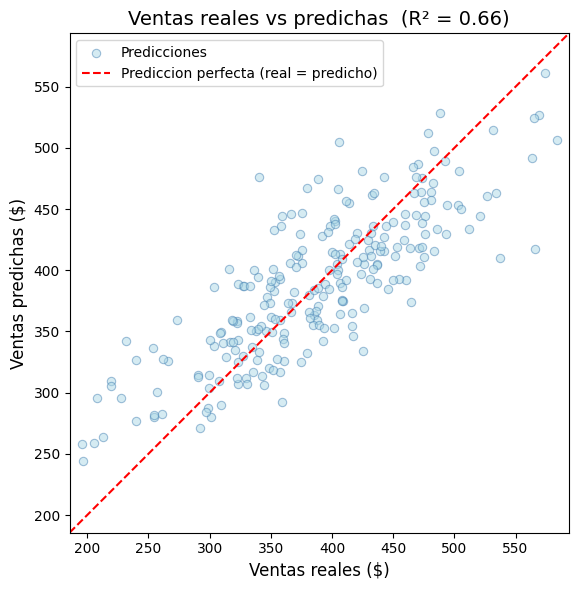

In [29]:
# --- Gráfica de Ventas Reales vs Predichas con línea de tendencia ---
fig, ax = plt.subplots(figsize=(8, 6))

# Cada punto es una observación del set de prueba
# Eje X = venta real, Eje Y = venta predicha por el modelo
ax.scatter(y_test, y_pred, alpha=0.5, edgecolors="steelblue",
           facecolors="lightblue", linewidths=0.8, label="Predicciones")

# Línea de predicción perfecta (donde real = predicho)
# Si el modelo fuera perfecto, todos los puntos estarían sobre esta línea
limite_min = min(y_test.min(), y_pred.min()) - 10
limite_max = max(y_test.max(), y_pred.max()) + 10
ax.plot([limite_min, limite_max], [limite_min, limite_max],
        color="red", linestyle="--", linewidth=1.5,
        label="Prediccion perfecta (real = predicho)")

# Etiquetas y título
ax.set_xlabel("Ventas reales ($)", fontsize=12)
ax.set_ylabel("Ventas predichas ($)", fontsize=12)
ax.set_title(f"Ventas reales vs predichas  (R² = {r2:.2f})", fontsize=14)
ax.legend(fontsize=10)

# Ajustar los ejes para que tengan la misma escala
ax.set_xlim(limite_min, limite_max)
ax.set_ylim(limite_min, limite_max)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Coeficientes del moodelo: ¿Qué variables pesan más?
Un modelo de regresion lineal es una forma de ***suma ponderada***

ventas = base + (peso1 % marketing) + (peso2 * precio) + (peso3 * temporada) + ...


In [30]:
# Extraer los coeficientes (peso) que el modelo aprendió

# Obtener los nombres de las columnas categóricas después del OneHotEncoding
ohe = pipe.named_steps["preprocess"].named_transformers_["cat"]
cat_cols = ohe.get_feature_names_out(["tienda", "canal"]).tolist()

# Lista completa de variables: numericas  + las generadas por el OneHotEncoding
feature_names = numeric_features + cat_cols

# Los coeficientes son los "pesos" de la fórmula:
# ventas = intercepto + coef1*marketing + coef2*precio + ... + coefN*canal_online
coef = pipe.named_steps["model"].coef_  # Coeficientes de cada variable



# Organizar de mayor a menor
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef
}).sort_values(by="coef",  ascending=False)

# Mostrar la tabla de coeficientes

print("="*50)
print("Coeficientes del modelo")
for _, fila in coef_df.iterrows():
    signo = "+" if fila["coef"] > 0 else ""
    barra = "^" if fila["coef"] > 0 else "v"
    print(f" {barra} {fila['feature']:20s} {signo}{fila['coef']:.4f}")


Coeficientes del modelo
 ^ tienda_Norte         +47.1291
 ^ temporada            +36.7398
 ^ canal_Mayorista      +36.1979
 ^ tienda_Centro        +18.9258
 ^ canal_Online         +0.0481
 ^ marketing            +0.0156
 v precio               -2.0794
 v tienda_Sur           -10.8698
 v tienda_Occidente     -14.8077
 v canal_Tienda         -36.2460
 v tienda_Oriente       -40.3773


In [31]:
row = X_test.iloc[[0]].copy()  # Tomamos la primera fila del set de prueba para hacer una predicción individual
print("datos de la observación seleccionada:")
print(row.to_string(index=False))

datos de la observación seleccionada:
 marketing  precio  temporada tienda  canal
   5659.18    35.3          3 Centro Online


In [32]:
pred_base = float(pipe.predict(row)[0])  # Predicción del modelo para esa fila

row_more_marketing = row.copy()
row_more_marketing["marketing"] = row_more_marketing["marketing"] * 1.10  # Aumentamos el gasto en marketing en 10%

pred_more_marketing = float(pipe.predict(row_more_marketing)[0])  # Predicción con más marketing

# -- calcular la diferencia
mkt_original = float(row["marketing"].values[0])
mkt_nuevo = float(row_more_marketing["marketing"].values[0])
diferencia = pred_more_marketing - pred_base

print("="*50)
print(f"inversion marketing original: ${mkt_original:.2f}")
print(f"inversion marketing (10%):    ${mkt_nuevo:.2f}")
print(f"aumento de la inversion: ${mkt_nuevo - mkt_original:.2f}")
print("="*50)

print(f"predicción de ventas (base): ${pred_base:.2f}")
print(f" predicción de ventas (+10%): ${pred_more_marketing:.2f}")
print(f" aumento en ventas por +10% marketing: ${diferencia:.2f}")
print("="*50)


inversion marketing original: $5659.18
inversion marketing (10%):    $6225.10
aumento de la inversion: $565.92
predicción de ventas (base): $444.61
 predicción de ventas (+10%): $453.45
 aumento en ventas por +10% marketing: $8.84
